# 📊 Telco Customer Churn Analysis

## 🔍 Project Overview

Customer churn — the phenomenon where customers stop using a company's services —
is one of the most critical challenges in the telecom industry. Retaining existing
customers is significantly more cost-effective than acquiring new ones, making churn
prediction and analysis a high-priority business problem.

This project performs an **Exploratory Data Analysis (EDA)** on the
**IBM Telco Customer Churn Dataset** to uncover patterns and key factors
that drive customer attrition.

---

## 📁 About the Dataset

- **Source:** IBM Sample Dataset (available on Kaggle)
- **Records:** 7,043 rows → 7,032 rows after cleaning
- **Features:** 21 columns covering customer demographics, service usage, and billing
- **Target Variable:** `Churn` — whether a customer left the company (Yes/No)

The dataset captures information about:
- **Customer demographics** — gender, age (senior citizen), partner, dependents
- **Services subscribed** — phone, internet, streaming, security, backup, tech support
- **Account details** — contract type, payment method, billing, tenure
- **Charges** — monthly charges and total charges

---

## 🎯 Project Objectives

1. **Understand the data** — explore structure, data types, and missing values
2. **Clean the data** — handle missing values, fix data types, encode target variable
3. **Perform EDA** — analyze churn distribution and patterns across key features
4. **Visualize insights** — create charts to communicate findings clearly
5. **Extract key insights** — identify the top factors driving customer churn

---

## 🛠️ Tools & Libraries Used

| Library | Purpose |
|---|---|
| `pandas` | Data loading, cleaning, and analysis |
| `matplotlib` | Base plotting library for charts |
| `seaborn` | Statistical visualizations (heatmap, boxplot, histogram) |

---

## 📌 Project Workflow
```
Step 1 → Data Loading & Setup
Step 2 → Data Cleaning (handle missing values, fix dtypes, encode target)
Step 3 → Exploratory Data Analysis (EDA)
Step 4 → Data Visualization (bar charts, histogram, boxplot, heatmap)
Step 5 → Key Insights & Conclusions
Step 6 → GitHub Upload
```

---

## 📊 Key Findings (Summary)

| Factor | Churn Rate |
|---|---|
| Month-to-month contract | 42.7% |
| Fiber optic internet | 41.9% |
| Senior citizens | 41.7% |
| Electronic check payment | 45.3% |
| New customers (0–12 months) | 47.7% |

> **Overall churn rate: 26.6%** (1,869 out of 7,032 customers)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
data.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [4]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
data.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [6]:
data.shape

(7043, 21)

In [7]:
churn_yes_count = data[data['Churn'] == 'Yes'].shape[0]
churn_no_count = data[data['Churn'] == 'No'].shape[0]
print(churn_yes_count)
print(churn_no_count)

1869
5174


In [8]:
# Converting the 'TotalCharges' -> 'object datatype' to 'float datatype' and remaining values to 'Nan',if there is any inappropriate data.

In [9]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'].astype(str).str.strip(),errors= 'coerce')

In [10]:
data.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [11]:
data.dropna(inplace=True)

In [12]:
data['Churn'] = data['Churn'].map({"Yes":1,"No":0})
data['Churn'].head(10)

0    0
1    0
2    1
3    0
4    1
5    1
6    0
7    0
8    1
9    0
Name: Churn, dtype: int64

In [13]:
data.drop('customerID',axis = 1)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1


#### Churn Distribution:
#### Churned(1) vs Stayed(0)

In [14]:
counts = data['Churn'].value_counts()
counts

Churn
0    5163
1    1869
Name: count, dtype: int64

#### Churn by Contract type

In [15]:
ch_contract = data.groupby('Contract')['Churn'].mean()*100
ch_contract

Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64

#### The data has tenure by month so generating a new column where the tenure with 'New','Mid','Senior','Loyal'.

In [16]:
data['TenureGroup'] = pd.cut(data['tenure'],
                             bins=[0,12,24,60,100],
                             labels=['New','Mid','Senior','Loyal'])
TenureGroup = data.groupby('TenureGroup',observed=False)['Churn'].mean()*100
TenureGroup

TenureGroup
New       47.678161
Mid       28.710938
Senior    18.342951
Loyal      6.609808
Name: Churn, dtype: float64

#### Churn by Internet Service

In [17]:
ch_internet = data.groupby('InternetService')['Churn'].mean()*100
ch_internet

InternetService
DSL            18.998344
Fiber optic    41.892765
No              7.434211
Name: Churn, dtype: float64

#### Churn by MonthlyCharges

In [18]:
data.groupby('Churn')['MonthlyCharges'].mean()

Churn
0    61.307408
1    74.441332
Name: MonthlyCharges, dtype: float64

#### Churn by SeniorCitizens

In [19]:
print(data.groupby('SeniorCitizen')['Churn'].mean()*100)

SeniorCitizen
0    23.650255
1    41.681261
Name: Churn, dtype: float64


#### Churn by PaymentMethod

In [20]:
print(data.groupby('PaymentMethod')['Churn'].mean()*100)

PaymentMethod
Bank transfer (automatic)    16.731518
Credit card (automatic)      15.253123
Electronic check             45.285412
Mailed check                 19.201995
Name: Churn, dtype: float64


In [21]:
print(data[['tenure','MonthlyCharges','TotalCharges','Churn']].corr())

                  tenure  MonthlyCharges  TotalCharges     Churn
tenure          1.000000        0.246862      0.825880 -0.354049
MonthlyCharges  0.246862        1.000000      0.651065  0.192858
TotalCharges    0.825880        0.651065      1.000000 -0.199484
Churn          -0.354049        0.192858     -0.199484  1.000000


#### Churn Distribution 

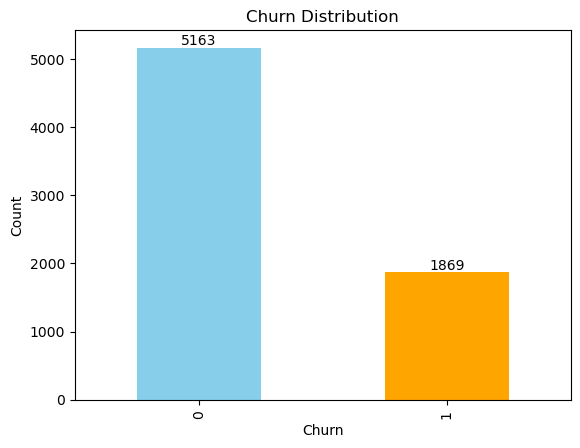

In [22]:
ax = counts.plot(kind='bar', color= ['skyblue','orange'])

ax.bar_label(ax.containers[0])

plt.title("Churn Distribution")
plt.xlabel('Churn')
plt.ylabel('Count')

plt.savefig('Churn_distribution.png')
plt.show()

#### Churn by Contract

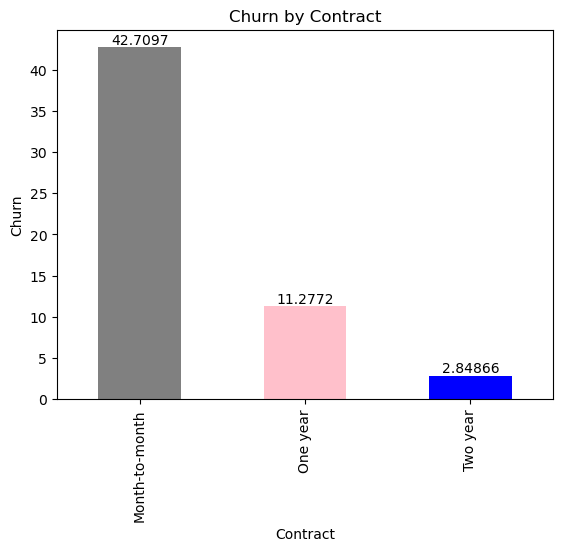

In [23]:
 # Group data by Contract and calculate churn rate (%)
 # Plot it as a bar chart
 # Save as churn_by_contract.png

cc = ch_contract.plot(kind='bar', color= ['grey','pink','blue'])
cc.bar_label(cc.containers[0])
plt.title("Churn by Contract")
plt.xlabel("Contract")
plt.ylabel("Churn")
plt.savefig("Churn_by_Contract.png")
plt.show()

#### Churn by Internet Service

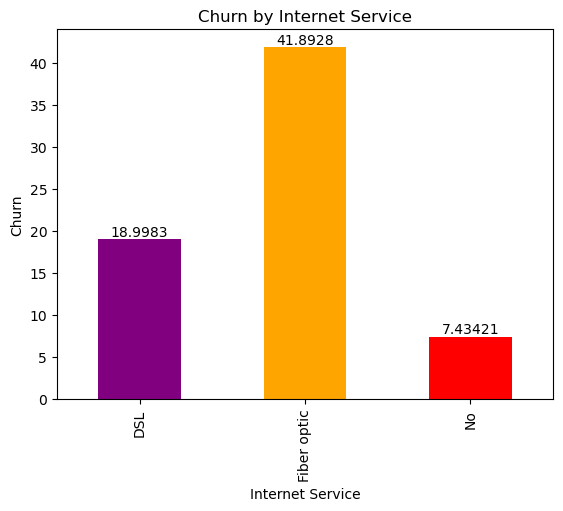

In [24]:
ci = ch_internet.plot(kind='bar', color=['purple','orange','red'])

ci.bar_label(ci.containers[0])
plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn")
plt.savefig("Churn_by_internet.png")
plt.show()

#### Tenure Distribution by Churn

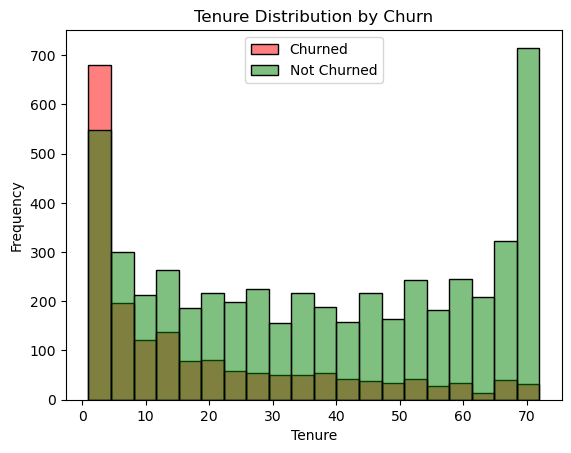

In [25]:
plt.figure()

sns.histplot(data=data[data['Churn']==1], 
             x='tenure', 
             bins= 20, 
             color='red',
             alpha=0.5,
             label='Churned'
            )
sns.histplot(data=data[data['Churn']==0], 
             x='tenure', 
             bins= 20, 
             color='green',
             alpha=0.5,
             label='Not Churned'
            )

plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure')
plt.ylabel('Frequency')
plt.legend()
plt.savefig('tenure_histogram.png',dpi=300, bbox_inches='tight')
plt.show()

#### Monthly Charges vs Churn

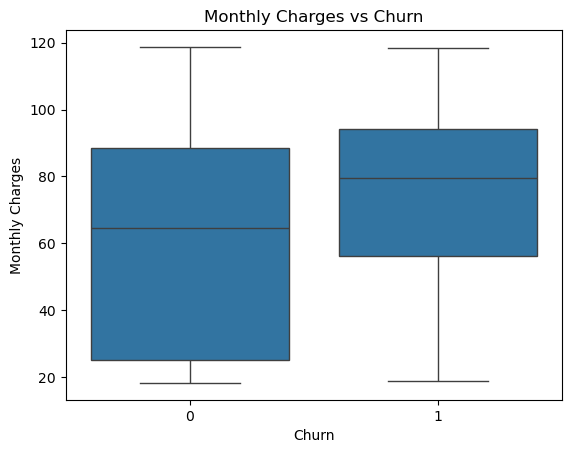

In [26]:
plt.figure()

sns.boxplot(
    data = data,
    x='Churn',
    y='MonthlyCharges'
)
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.savefig('boxplot_monthly_charges.png', dpi=300, bbox_inches='tight')
plt.show()

#### Correlation Matrix for tenure,monthlycharges,totalcharges,churn.

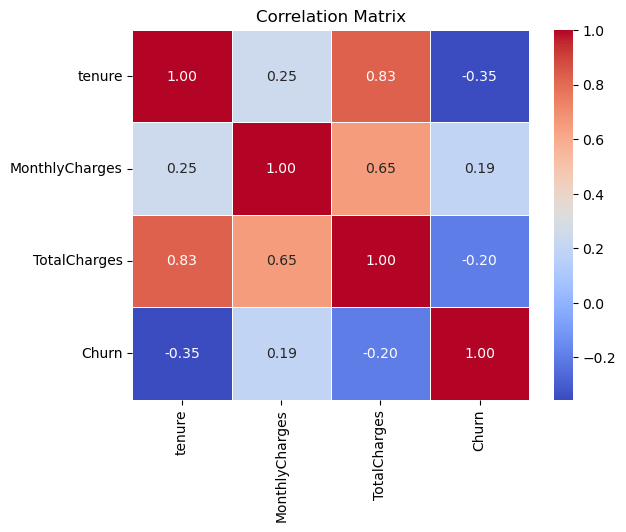

In [27]:
corr_data = data[['tenure','MonthlyCharges','TotalCharges','Churn']]

corr_matrix = corr_data.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt='.2f'
)
plt.title("Correlation Matrix")
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

# Key Insights & Conclusion

## Churn Risk Factors

- Month-to-month contract — 42.7% churn rate
- New customer (low tenure) — 47.7% churn in first year
- Fiber optic internet — 41.9% churn rate
- Electronic check payment — 45.3% churn rate
- Senior citizen — 41.7% churn rate

## Conclusion 

The analysis of the Telco dataset reveals that short-term contracts, early customer tenure, high monthly charges, and certain service types are the strongest predictors of churn. Businesses can reduce churn by offering long-term contract incentives, improving the onboarding experience for new customers, and reviewing pricing for fiber optic plans and electronic check billing.